# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [181]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [182]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [183]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [184]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2021.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2021.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [185]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

2012

In [186]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

2012

Combine the datasets

In [187]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [188]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [189]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [190]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2021 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2021

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((32301.102 171674.743, 32280.3 ...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((32272.065 172366.455, 32263 17...",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((30939.774 171990.166, 30937.77...",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((30862.104 171940.677, 30853.33...",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31355.78 171872.35, 31351.28 1...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((36141.471 182210.701, 36055.85...",bl,215,gh
14789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((194749.739 187735.036, 194723....",se + kbq°,213,gh
3887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((176131.914 214009.653, 176086....",hp* + uv° + kbpica,215,gh
15722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((119616.172 183159.173, 119588....",hrb + kj°,214,gh


Convert multipolygon to points.

In [191]:
datagrassbwk2021["geometry"] = datagrassbwk2021.geometry.centroid
datagrassbwk2021

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31305.19 171237.607),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (32264.457 172390.412),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (30939.356 171995.492),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (30853.325 171951.609),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31351.193 171873.578),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (36057.216 182438.417),bl,215,gh
14789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (194739.702 187753.353),se + kbq°,213,gh
3887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (176099.859 214031.088),hp* + uv° + kbpica,215,gh
15722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (119605.144 183193.428),hrb + kj°,214,gh


<Axes: >

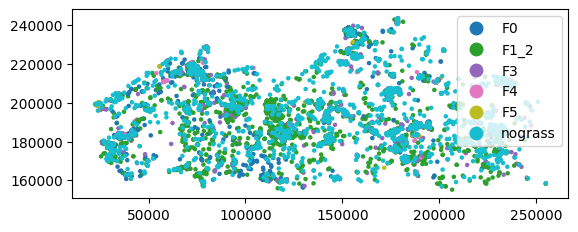

In [192]:
datagrassbwk2021.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [193]:
points_ee = datagrassbwk2021.to_crs("EPSG:4326")
points_ee


,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68348 50.83944),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.69673 50.84999),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.67804 50.84617),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.67684 50.84576),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68393 50.84516),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (2.74746 50.94105),bl,215,gh
14789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (5.00609 50.99827),se + kbq°,213,gh
3887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (4.74245 51.23561),hp* + uv° + kbpica,215,gh
15722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (3.93614 50.95822),hrb + kj°,214,gh


In [194]:
import ee
try:
    ee.Initialize(project="ee-sebastiaanverbesselt")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

print('Earth Engine version:', ee.__version__)
print('geemap version:', geemap.__version__)



Earth Engine version: 1.7.30
geemap version: 0.38.0


In [195]:
def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        features.append(
            ee.Feature(geom, {
                "id": row.name,
                "class": str(row["Level4"]) # Fixed: extracts the actual row value (e.g., 'F0', 'nograss')
            })
        )
    return ee.FeatureCollection(features)

fc = gdf_to_ee(points_ee)


In [196]:
collection_id = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"

In [197]:
# Filter the collection for your year

image_coll = (
    ee.ImageCollection(collection_id)
    .filterDate("2021-01-01", "2022-01-01")
)

# Mosaic the overlapping UTM tiles into a single coherent image
image = image_coll.mosaic()

samples_fc = image.sampleRegions(
    collection=fc,
    scale = 10,
    geometries=True
)

samples_fc

/usr/local/lib/python3.12/dist-packages/IPython/core/formatters.py:345: UserWarning: Getting info failed with: 'Collection query aborted after accumulating over 5000 elements.'. Falling back to string repr.
  return method()


In [198]:
# Use Earth Engine's computeFeatures API to stream pages of vector data
# directly into a native GeoPandas GeoDataFrame
embeddings_gdf = ee.data.computeFeatures({
    'expression': samples_fc,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

# Explicitly re-assign the WGS 84 Coordinate Reference System
embeddings_gdf.crs = 'EPSG:4326'

In [199]:
embeddings_gdf

,geometry,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A56,A57,A58,A59,A60,A61,A62,A63,class,id
0,POINT (2.68349 50.83948),-0.214133,-0.048228,-0.147697,-0.084214,-0.013841,-0.153787,0.192910,-0.010396,0.160000,...,-0.059116,-0.084214,-0.066990,-0.179377,-0.048228,-0.172795,-0.048228,0.003937,F1_2,0
1,POINT (2.6967 50.84999),-0.221453,-0.221453,-0.147697,0.044844,-0.059116,-0.186082,0.093564,0.008858,0.166336,...,-0.124567,-0.038447,-0.035433,-0.012057,0.130165,-0.079723,-0.007443,-0.147697,F1_2,1
2,POINT (2.67801 50.84622),-0.179377,-0.221453,-0.166336,0.071111,0.013841,-0.244152,0.141730,0.059116,0.147697,...,-0.103406,0.066990,-0.108512,-0.041584,0.103406,-0.135886,-0.029773,-0.059116,F1_2,2
3,POINT (2.67684 50.84577),-0.221453,-0.310096,-0.172795,0.029773,0.012057,-0.135886,0.093564,-0.062991,0.135886,...,-0.093564,0.022207,-0.038447,-0.071111,0.130165,-0.093564,0.041584,-0.130165,F1_2,3
4,POINT (2.68394 50.84514),-0.221453,-0.147697,-0.160000,-0.044844,0.032541,-0.153787,0.147697,0.029773,0.153787,...,-0.066990,-0.059116,-0.066990,-0.108512,0.024606,-0.147697,-0.084214,-0.079723,F1_2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,POINT (2.74745 50.94108),-0.147697,-0.035433,-0.071111,-0.130165,-0.029773,-0.084214,0.135886,-0.071111,0.075356,...,-0.130165,-0.084214,-0.000246,-0.130165,0.032541,-0.147697,0.051734,-0.041584,nograss,13020
8714,POINT (5.00609 50.9983),-0.192910,-0.147697,-0.130165,0.035433,0.015748,-0.179377,-0.010396,-0.008858,0.098424,...,0.051734,-0.019931,-0.027128,-0.108512,0.071111,-0.119093,0.041584,-0.055363,nograss,14789
8715,POINT (4.74243 51.23564),-0.147697,-0.259900,-0.186082,-0.004983,-0.075356,-0.206936,-0.048228,0.108512,0.130165,...,0.029773,0.113741,-0.079723,0.029773,0.066990,-0.147697,0.141730,0.003937,nograss,3887
8716,POINT (3.9361 50.95824),-0.214133,-0.199862,-0.124567,0.071111,0.019931,-0.206936,0.130165,0.135886,0.071111,...,0.013841,-0.006151,-0.022207,0.062991,0.035433,-0.186082,-0.048228,-0.062991,nograss,15722


In [200]:
embeddings_gdf.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2021.csv") # Now saved in WGS 84